# Ensemble Learning

Ensemble Learning is a machine learning technique that **combines two or
more learners/models** to produce better predictions.

The basic idea is:

> Instead of depending on one model, combine multiple models so that
> their strengths can compensate for each other's weaknesses.

## Why Do We Need Ensemble Learning?

A single model can have two common problems:

### 1. Underfitting

-   **High Bias**
-   **Low Variance**
-   The model is too simple.
-   It fails to learn important patterns from the data.

### 2. Overfitting

-   **Low Bias**
-   **High Variance**
-   The model is too complex.
-   It learns the training data too closely and may perform poorly on
    unseen data.

Ensemble Learning combines multiple learners to improve **accuracy,
stability, and generalization**.

------------------------------------------------------------------------

# Main Types of Ensemble Learning

The two important ensemble techniques are:

1.  **Bagging**
2.  **Boosting**

The main difference is **how the models are trained**.

------------------------------------------------------------------------

# 1. Bagging

**Bagging** stands for **Bootstrap Aggregating**.

In Bagging, multiple models are trained **independently and in
parallel**.

``` text
                ┌──> Model 1 ──┐
Input Data ─────┼──> Model 2 ──┼──> Aggregate Predictions
                └──> Model 3 ──┘
```

Each model learns independently. Their predictions are then combined to
produce the final prediction.

## Why Do We Use Bagging?

The main purpose of Bagging is to:

**Reduce variance and make the model more stable.**

This is especially useful when an individual model has a tendency to
**overfit**.

### For Classification

Predictions can be combined using **majority voting**.

Example:

``` text
Model 1 → Spam
Model 2 → Not Spam
Model 3 → Spam

Spam       → 2 votes
Not Spam   → 1 vote

Final Prediction → Spam
```

### For Regression

Predictions can generally be combined by taking their **average**.

Example:

``` text
Model 1 → 80
Model 2 → 84
Model 3 → 82

Final Prediction = (80 + 84 + 82) / 3
                 = 82
```

## Example

**Random Forest** is a well-known Bagging-based ensemble method.

It combines many decision trees and aggregates their predictions.

------------------------------------------------------------------------

# 2. Boosting

Boosting works differently from Bagging.

In Boosting, models are trained **sequentially**, one after another.

``` text
Data → Model 1 → Model 2 → Model 3 → Model 4
          ↓         ↓         ↓
        Errors    Errors    Errors
```

The next model focuses more on the errors or weaknesses of the previous
models.

## Why Do We Use Boosting?

The main purpose of Boosting is to:

**Reduce bias and improve predictive accuracy.**

It gradually builds a strong learner from several weaker learners.

A weak learner may perform only slightly better than random guessing. By
combining many weak learners, Boosting can create a much stronger model.

## Basic Idea

``` text
Model 1
   ↓
Find mistakes
   ↓
Model 2 focuses on previous mistakes
   ↓
Find remaining mistakes
   ↓
Model 3 focuses on them
   ↓
Final Strong Model
```

------------------------------------------------------------------------



# Bagging vs Boosting

| Feature | Bagging | Boosting |
|---|---|---|
| Training | Parallel | Sequential |
| Main Purpose | Reduce variance | Reduce bias |
| Main Focus | Stability | Accuracy |
| Models | Independent | Dependent on previous models |
| Example | Random Forest | AdaBoost, Gradient Boosting, XGBoost |

------------------------------------------------------------------------

# Easy Way to Remember

## Bagging

**Parallel → Reduce Variance**

``` text
M1 ──┐
M2 ──┼──> Aggregate
M3 ──┘
```

The models work **independently**.

## Boosting

**Sequential → Reduce Bias improve accuracy**

``` text
M1 → M2 → M3 → M4
```

Each new model learns from the **mistakes of previous models**.

------------------------------------------------------------------------

# Summary

``` text
                 Ensemble Learning
                        |
              +---------+---------+
              |                   |
           Bagging             Boosting
              |                   |
        Parallel models      Sequential models
              |                   |
        Reduce Variance       Reduce Bias
              |                   |
         Random Forest      AdaBoost / XGBoost
```

### Key Points

-   **Ensemble Learning** combines multiple learners to produce better
    predictions.
-   **Bagging** trains models in parallel and mainly **reduces
    variance**.
-   **Boosting** trains models sequentially and mainly **reduces bias**.
-   Bagging is useful for improving **stability**.
-   Boosting is useful for improving **accuracy**.


# Bagging

**Bagging (Bootstrap Aggregating)** is an ensemble learning technique that trains **multiple base learners independently** using different modified samples of the same training dataset, and then **combines their predictions** to produce the final prediction.

The main purpose of Bagging is to **reduce variance and improve the stability of the model**.

---

## How Bagging Works

The complete process can be divided into **3 main steps**:

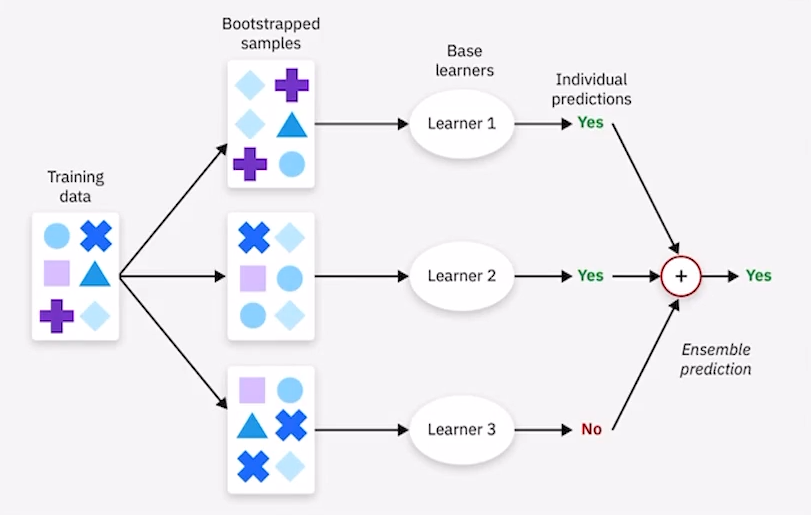

### Step 1: Data Sampling

We start with the original training dataset.

From this dataset, we create multiple **bootstrap samples**.

Bootstrap sampling means:

> We randomly select samples **with replacement**.

Because sampling is done with replacement, the same data point can appear multiple times in one bootstrap sample, while some data points may not appear at all.

For example:

```text
Original Dataset:

D = [A, B, C, D, E]

Bootstrap Sample 1:
[A, C, C, E, A]

Bootstrap Sample 2:
[B, B, D, A, E]

Bootstrap Sample 3:
[C, D, D, E, B]
```

These samples are different from each other even though they come from the same original dataset.

The purpose of creating different samples is to make the base learners **different from each other**.

---

### Step 2: Model Training

Now we train a separate **base learner** on each bootstrap sample.

```text
Bootstrap Sample 1 → Learner 1
Bootstrap Sample 2 → Learner 2
Bootstrap Sample 3 → Learner 3
```

The models are trained **independently and in parallel**.

For example, if we use Decision Trees:

```text
Sample 1 → Decision Tree 1
Sample 2 → Decision Tree 2
Sample 3 → Decision Tree 3
```

Usually, the same training algorithm is used for all the base learners.

The important point is that the learners see **different versions of the training data**, so they can make different predictions.

---

### Step 3: Aggregation

After training, every learner makes its own prediction for a new data point.

```text
              ┌→ Learner 1 → Yes
New Data ─────┼→ Learner 2 → Yes
              └→ Learner 3 → No
```

Now we combine these individual predictions.

The aggregation method depends on the type of problem.

### Classification

For classification, we generally use **majority voting**.

```text
Learner 1 → Yes
Learner 2 → Yes
Learner 3 → No

Yes = 2 votes
No  = 1 vote

Final Prediction → Yes
```

### Regression

For regression, we generally use the **mean/average** of the predictions.

```text
Learner 1 → 12
Learner 2 → 15
Learner 3 → 18

Final Prediction = (12 + 15 + 18) / 3
                 = 15
```

---

# Why Does Bagging Work?

The main problem Bagging tries to solve is **high variance**.

Suppose one decision tree overfits the training data and makes a slightly different prediction when the training data changes.

Instead of relying on one tree:

```text
One Decision Tree
       ↓
   Prediction
```

we train many trees:

```text
Tree 1 ──┐
Tree 2 ──┤
Tree 3 ──┼──→ Aggregation → Final Prediction
Tree 4 ──┤
Tree 5 ──┘
```

Because the trees are trained on different bootstrap samples, their errors are not exactly the same.

When their predictions are combined, individual errors can **cancel each other out**.

Therefore:

```text
Bagging
   ↓
Multiple learners
   ↓
Different bootstrap samples
   ↓
Independent predictions
   ↓
Aggregation
   ↓
Reduced Variance
   ↓
More Stable Model
```

---

# Random Forest and Bagging

**Random Forest** is a famous example of a Bagging-based ensemble method.

It uses multiple decision trees and combines their predictions.


---

# Complete Bagging Process

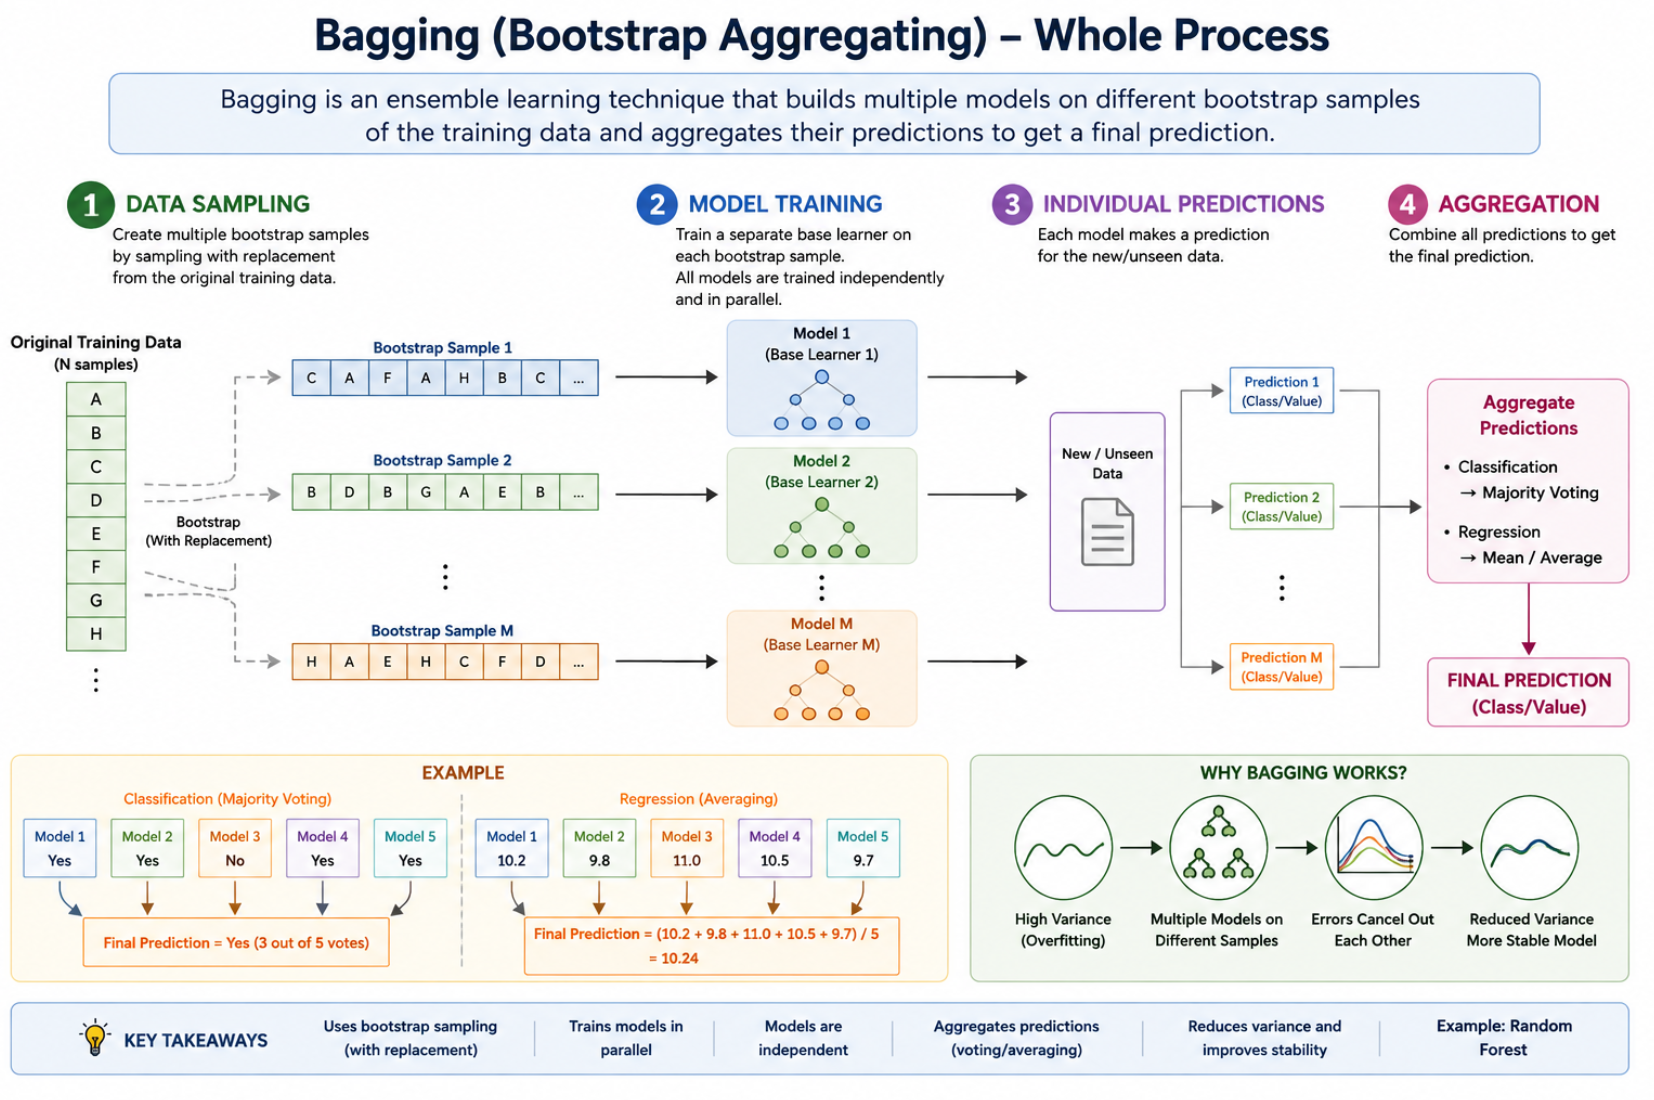

```text
Original Training Data
          ↓
Bootstrap Sampling
          ↓
 ┌────────┼────────┐
 ↓        ↓        ↓
Sample 1  Sample 2  Sample 3
 ↓        ↓        ↓
Learner 1 Learner 2 Learner 3
 └────────┼────────┘
          ↓
   Individual Predictions
          ↓
      Aggregation
          ↓
 Classification → Majority Voting
 Regression     → Mean/Average
          ↓
     Final Prediction
```

## Key Points to Remember

- **Bagging = Bootstrap Aggregating**
- Uses **bootstrap sampling**
- Sampling is done **with replacement**
- Creates multiple modified training datasets
- Trains multiple **independent base learners**
- Learners can be trained **in parallel**
- **Classification → Majority Voting**
- **Regression → Mean/Average**
- Main purpose → **Reduce Variance**
- Result → **More stable and less sensitive model**
- **Random Forest** is a major example of Bagging
---
---

# Boosting

**Boosting** is an ensemble learning technique in which models are trained **sequentially**. Each new model tries to correct the mistakes made by the previous model.

The main purpose of Boosting is to **reduce bias and improve accuracy**.

---

## Whole Process of Boosting

The process can be understood in two main ideas:

1. **Sequential Training**
2. **Weight Adjustment**

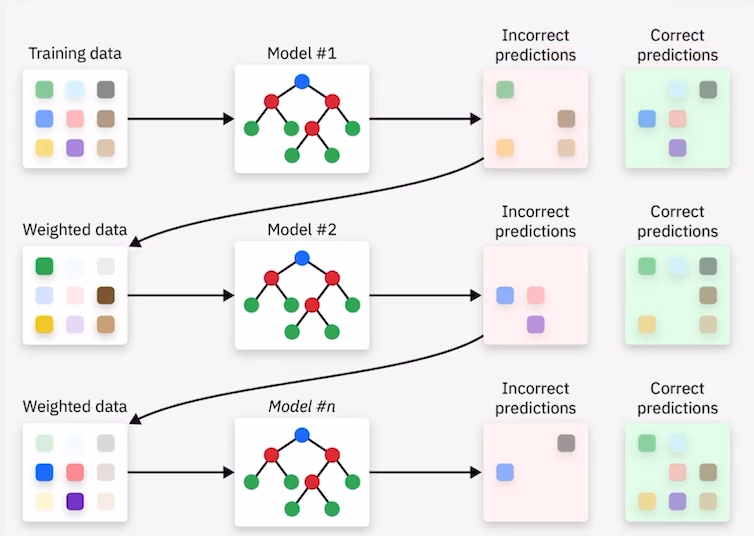

---

## Step 1: Start with Training Data

We begin with the original training dataset.

Initially, every training sample is given an **equal weight**.

For example, if there are 6 samples:

```text
Sample 1 → 1/6
Sample 2 → 1/6
Sample 3 → 1/6
Sample 4 → 1/6
Sample 5 → 1/6
Sample 6 → 1/6
```

Here, **weight represents the importance given to a training sample**.

At the beginning, all samples have the same importance.

---

## Step 2: Train the First Model

Train the first base learner using the training data.

```text
Training Data
      ↓
   Model 1
```

The first model makes predictions on the training samples.

---

## Step 3: Find the Mistakes

Compare the model's predictions with the actual target values.

The samples can now be divided into:

- **Correctly predicted samples**
- **Incorrectly predicted samples**

For example:

```text
Sample 1 → Correct
Sample 2 → Incorrect
Sample 3 → Correct
Sample 4 → Correct
Sample 5 → Incorrect
Sample 6 → Correct
```

The important point is that Boosting pays special attention to the **incorrectly predicted samples**.

---

## Step 4: Adjust the Weights

Now the weights of the training samples are changed.

### Incorrectly predicted samples

Their weights are **increased**.

This makes them more important for the next model.

### Correctly predicted samples

Their weights are **decreased** or become relatively less important.

The idea is:

```text
Incorrect prediction
        ↓
Increase weight
        ↓
More importance
        ↓
Next model focuses on it
```

**Weight = Importance**

---

## Step 5: Train the Next Model

Now train the second model using the **updated/weighted data**.

```text
Updated Weights
      ↓
   Model 2
      ↓
New Predictions
```

Because incorrectly predicted samples have higher weights, Model 2 focuses more on the difficult samples that Model 1 failed to classify correctly.

---

## Step 6: Repeat the Process

The process continues sequentially.

```text
Model 1
   ↓
Find mistakes
   ↓
Adjust weights
   ↓
Model 2
   ↓
Find mistakes
   ↓
Adjust weights
   ↓
Model 3
   ↓
...
   ↓
Model M
```

Each new model tries to improve the mistakes made by the previous models.

This is the key difference between Boosting and Bagging:

```text
Bagging:
M1 ──┐
M2 ──┼──→ Aggregate
M3 ──┘

Boosting:
M1 → M2 → M3 → M4
```

In Bagging, models are generally independent.

In Boosting, models are **dependent on the previous models**.

---

## Step 7: Combine the Models

After training multiple models, their predictions are combined to produce the final prediction.

The models can have different importance depending on how well they perform.

### Classification

For classification, predictions can be combined using **weighted voting**.

A model that performs better can have a greater influence on the final prediction.

```text
Model 1 → Prediction A → Weight 0.6
Model 2 → Prediction B → Weight 0.3
Model 3 → Prediction A → Weight 0.1

Final prediction is based on the weighted votes.
```

### Regression

For regression, predictions can be combined using a **weighted average**.

---

# Why Does Boosting Work?

The main idea is that one weak model does not have to solve the entire problem.

Instead:

```text
Model 1
   ↓
Makes some mistakes
   ↓
Model 2 focuses more on those mistakes
   ↓
Makes new/remaining mistakes
   ↓
Model 3 focuses on them
   ↓
...
   ↓
Strong Final Model
```

By repeatedly focusing on difficult samples, the ensemble gradually improves its predictive performance.

---

# Complete Boosting Flow

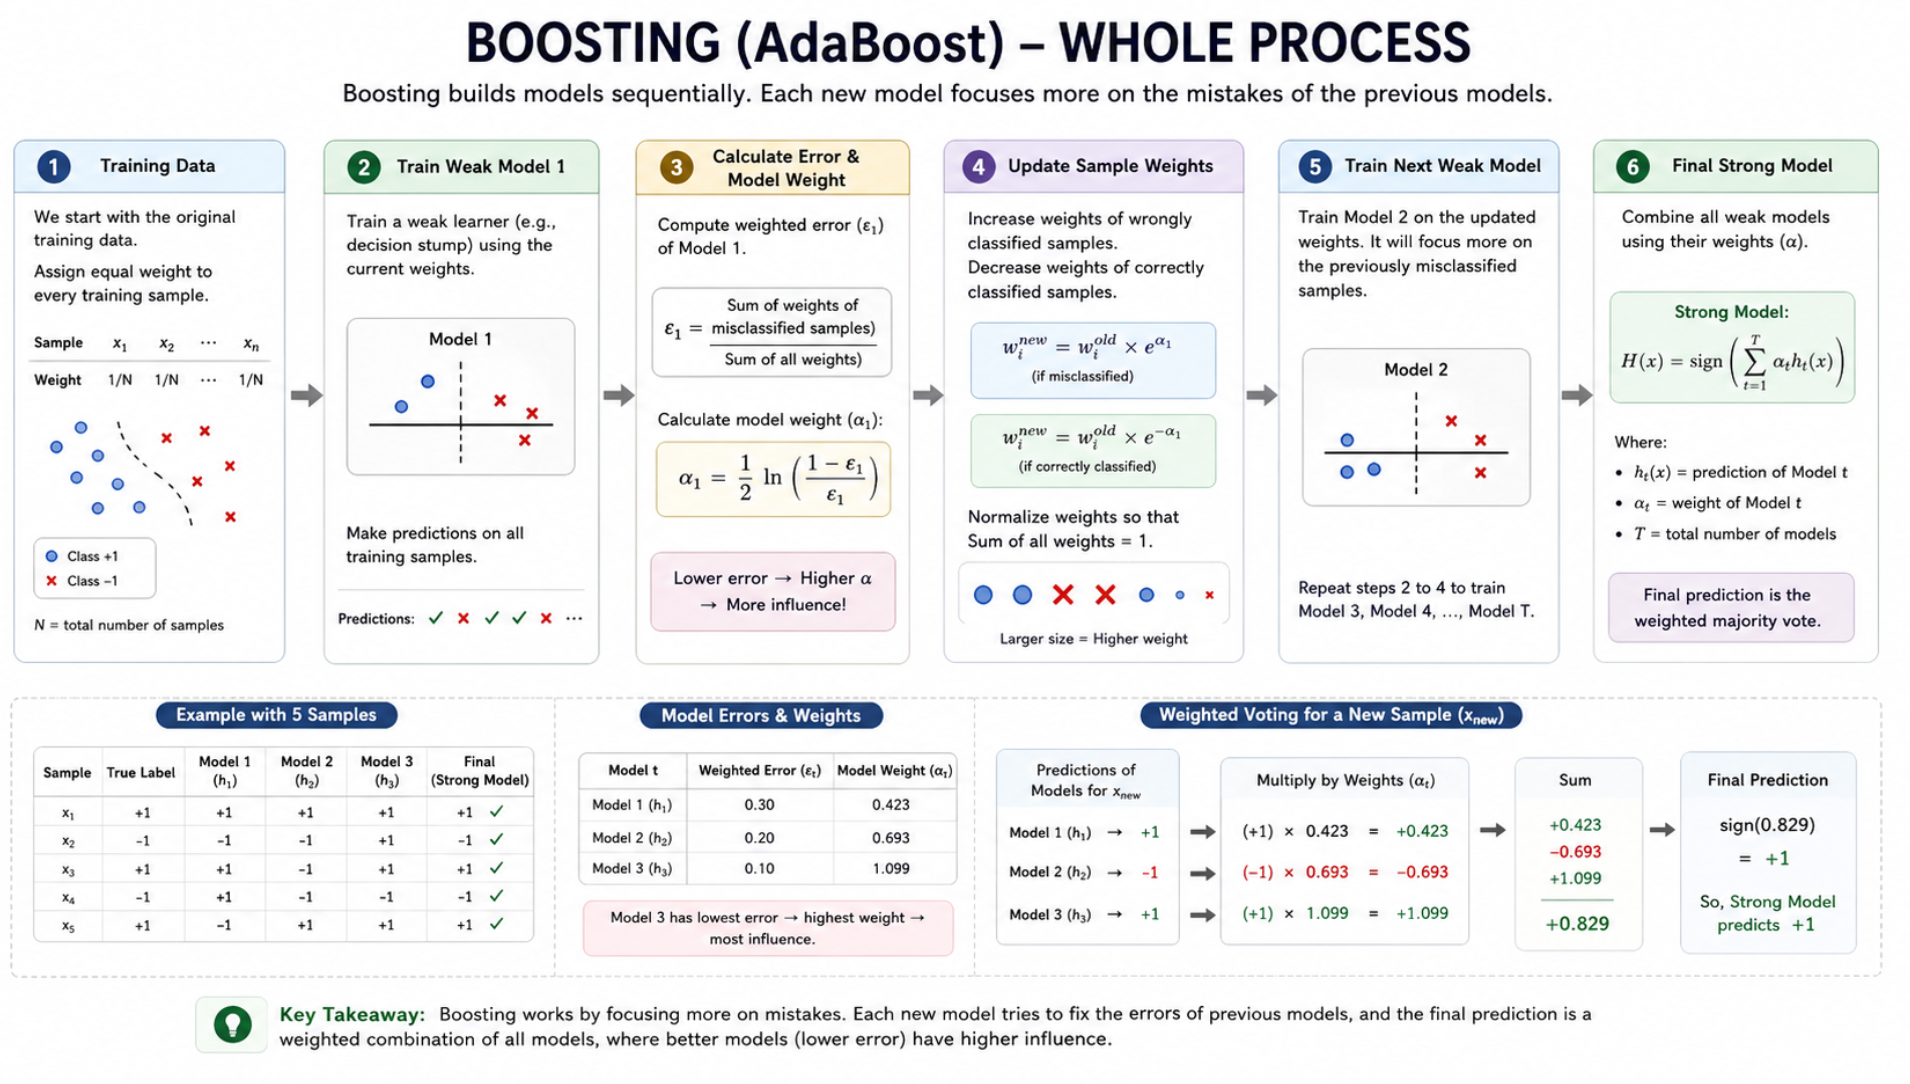

```text
Original Training Data
          ↓
Equal Initial Weights
          ↓
      Train Model 1
          ↓
   Make Predictions
          ↓
   Find Incorrect Samples
          ↓
    Adjust Weights
          ↓
Incorrect samples get more importance
          ↓
      Train Model 2
          ↓
   Make Predictions
          ↓
   Find Incorrect Samples
          ↓
    Adjust Weights
          ↓
      Train Model 3
          ↓
          ⋮
          ↓
      Train Model M
          ↓
   Combine All Models
          ↓
 Weighted Voting / Weighted Average
          ↓
     Final Prediction
```

---

# Why Boosting Reduces Bias

A single weak learner may be too simple and therefore have **high bias**.

Boosting combines many weak learners sequentially.

```text
Weak Learner
     +
Weak Learner
     +
Weak Learner
     +
...
     ↓
Strong Learner
```

Therefore, Boosting mainly aims to **reduce bias and improve accuracy**.

---

# Examples of Boosting Algorithms

Common Boosting algorithms include:

- **AdaBoost**
- **Gradient Boosting**
- **XGBoost**

---

## Key Points to Remember

- Boosting trains models **sequentially**.
- Each new model tries to correct previous mistakes.
- Initially, training samples have **equal weights**.
- Incorrectly predicted samples receive **more importance**.
- The next model focuses more on difficult samples.
- The process is repeated for multiple models.
- Final predictions are combined using **weighted voting or weighted averaging**.
- Main purpose: **Reduce bias and improve accuracy**.
- Examples: **AdaBoost, Gradient Boosting, XGBoost**.


# Out-of-Bag (OOB)

**Out-of-Bag (OOB)** is a built-in validation method used in **`Bagging-based models`**, especially **Random Forest**, to estimate model performance **without using a separate validation set**.

- The OOB calculation is **automatic** once you enable it, but it is **not mandatory**

---

## Why Do We Need OOB?

In Bagging, each model is trained using **bootstrap sampling with replacement**.

Because we sample with replacement, not every training example gets selected for every tree.

The examples that are **not selected** for a particular tree are called its:

> **Out-of-Bag (OOB) samples**

These unused samples can be used to test that tree.

---

## Step 1: Bootstrap Sampling

Suppose the original dataset contains `n` samples.

We create a bootstrap sample by randomly selecting `n` samples **with replacement**.

```text
Original Dataset
       ↓
Bootstrap Sampling
       ↓
 ┌───────────────┐
 │ Training Data │ → Used to train the tree
 └───────────────┘

Samples not selected
       ↓
 OOB Samples
       ↓
Used for validation
```

For example:

```text
Original:
[A, B, C, D, E]

Bootstrap sample:
[A, C, C, E, A]

OOB samples:
[B, D]
```

Here:

- `A, C, E` are used for training.
- `B, D` are not selected.
- Therefore, `B` and `D` are the **OOB samples** for this tree.

---

## Step 2: Train the Model

The bootstrap sample is used to train a Decision Tree.

```text
Bootstrap Sample
       ↓
Decision Tree
       ↓
Trained Model
```

The OOB samples are **not used to train this particular tree**.

---

## Step 3: Test Using OOB Samples

Now we use the OOB samples to make predictions with the tree.

```text
OOB Samples
     ↓
Trained Tree
     ↓
Predictions
```

Because these samples were not used to train that tree, they can act like a small validation set for that tree.

---

## Step 4: Repeat for All Trees

Random Forest contains many Decision Trees.

Each tree has its own bootstrap sample and therefore its own OOB samples.

```text
Dataset
   ↓
Bootstrap Sampling
   ↓
 ┌────────┬────────┬────────┐
 ↓        ↓        ↓
Tree 1   Tree 2   Tree 3
 ↓        ↓        ↓
OOB 1    OOB 2    OOB 3
```

A particular sample may be:

- Used for training by some trees
- OOB for other trees

---

## Step 5: Combine OOB Predictions

For each training sample, we collect predictions from the trees for which that sample was OOB.

For classification:

```text
Sample A:

Tree 1 → Yes
Tree 3 → Yes
Tree 5 → No

Majority → Yes
```

For regression:

```text
Sample A:

Tree 1 → 20
Tree 3 → 24
Tree 5 → 22

Average → 22
```

This gives an **OOB prediction** for the sample.

---

## Step 6: Calculate OOB Performance

We compare the OOB predictions with the actual target values.

For classification, we can calculate metrics such as:

```text
OOB Accuracy
OOB Error
```

For regression, we can use appropriate regression metrics such as:

```text
OOB Error
OOB R²
```

The exact metric depends on the problem.

---

# Why Is OOB Useful?

The main advantage is that we can estimate model performance **without creating a separate validation set**.

Normally:

```text
Dataset
   ↓
Train Set + Validation Set
```

With OOB:

```text
Dataset
   ↓
Bootstrap Samples
   ↓
Training + OOB Samples
   ↓
OOB Performance Estimate
```

This means more of the available data can remain part of the overall training process while the unused samples provide validation information for individual trees.

---

# OOB in Random Forest

The complete idea is:

```text
Original Dataset
       ↓
Bootstrap Sampling
       ↓
 ┌────────┬────────┬────────┐
 ↓        ↓        ↓
Tree 1   Tree 2   Tree 3
 ↓        ↓        ↓
OOB 1    OOB 2    OOB 3
 └────────┬────────┘
          ↓
   OOB Predictions
          ↓
      Compare with
      Actual Values
          ↓
   OOB Performance
```

---

## Important Fact

When a dataset has `n` samples and we draw `n` samples with replacement, approximately **36.8% of the unique observations are expected to be left out** of a bootstrap sample.

So approximately:

```text
≈ 63.2% → selected at least once
≈ 36.8% → OOB
```
That is why 1/3 of the dataset is OOB. 2/3 of the entire dataset is used in training. 1/3 in oob.

This is why OOB samples provide a useful built-in source of validation data.

---

# OOB vs Validation Set

| Feature | OOB | Separate Validation Set |
|---|---|---|
| Data Source | Unselected bootstrap samples | Explicitly held-out data |
| Extra Split Required | No | Yes |
| Mainly Used With | Bagging / Random Forest | General ML models |
| Purpose | Estimate model performance | Validate model performance |

---

## Key Points to Remember

- **OOB = Out-of-Bag**
- It is mainly associated with **Bagging and Random Forest**.
- The OOB calculation is **automatic** once you enable it, but it is **not mandatory**
- It comes from **bootstrap sampling with replacement**.
- Samples not selected for a tree are its **OOB samples**.
- OOB samples can be used to evaluate that tree.
- Predictions from relevant trees are combined to obtain an OOB prediction.
- OOB predictions are compared with the actual values.
- This gives an estimate of model performance.
- OOB allows us to estimate performance **without a separate validation set**.

> **Easy way to remember: OOB = Samples left outside a tree's bootstrap bag, used to test that tree.**


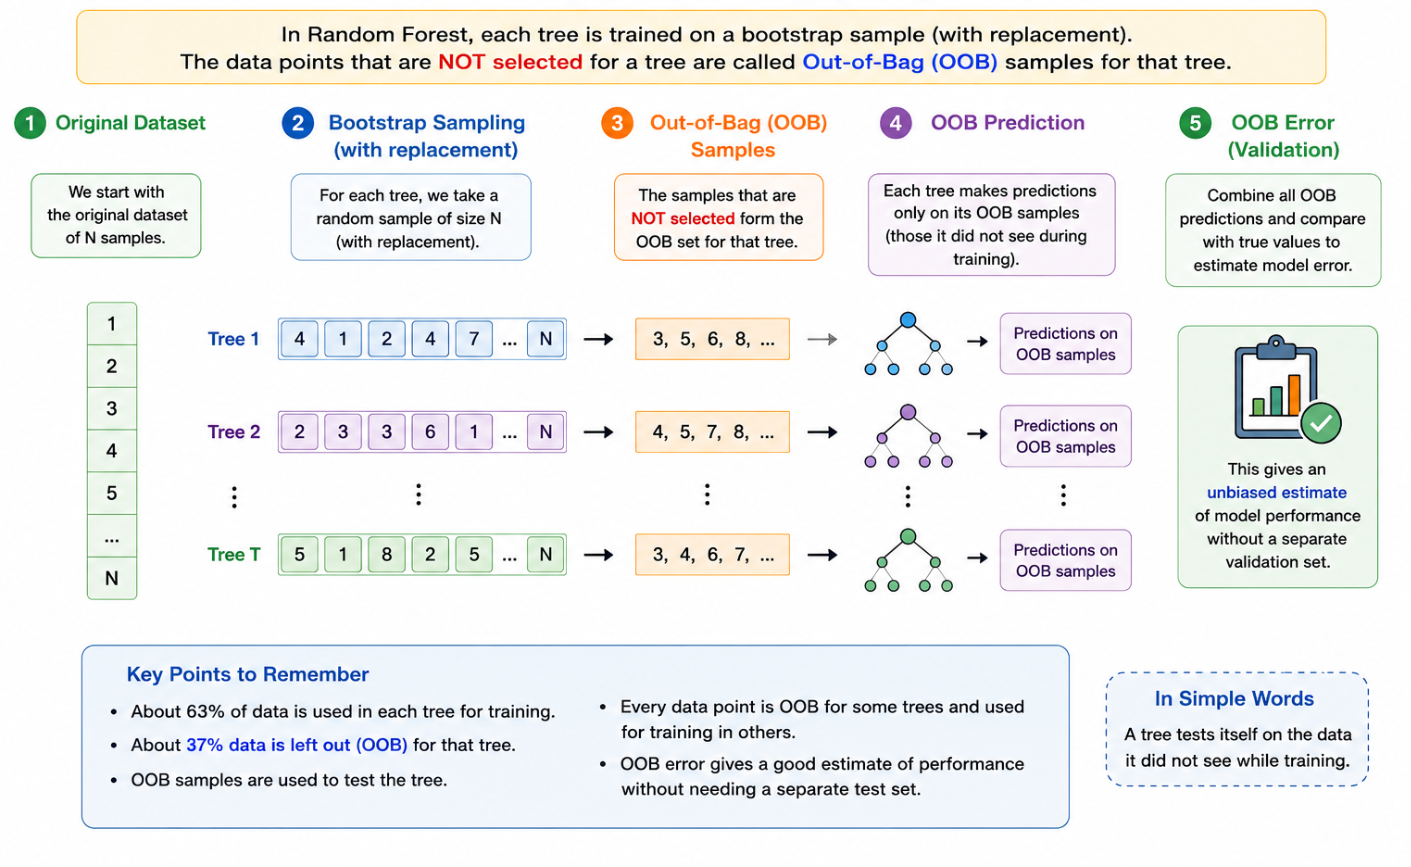

# Gradient Boosting

## What is Gradient Boosting?

**Gradient Boosting** is an ensemble learning technique that builds models **sequentially**.

Instead of training all models independently, each new model tries to **correct the mistakes made by the previous models**.

The models are usually small Decision Trees, called **weak learners**.

### Main idea

```text
Initial Model
     ↓
Find mistakes
     ↓
Train a new weak model to correct them
     ↓
Update predictions
     ↓
Find remaining mistakes
     ↓
Train another weak model
     ↓
Repeat
     ↓
Final strong model
```

The goal is to gradually improve the predictions and reduce the overall error.

---

## Why do we use Gradient Boosting?

A single simple model may not be accurate enough.

Gradient Boosting combines many **weak learners** so that:

- each new learner improves the previous model
- errors are gradually reduced
- the final model becomes much stronger
- prediction accuracy can improve

Unlike **Bagging**, where models are trained independently and in parallel, Gradient Boosting trains models **one after another**.

---

## Gradient Boosting Formula

The main formula used in Gradient Boosting is:

$$
F_m(x) = F_{m-1}(x) + \eta \cdot f_m(x)
$$

Where:

- $F_m(x)$ = updated model after step $m$
- $F_{m-1}(x)$ = previous model
- $f_m(x)$ = new weak learner trained to correct the previous model's errors
- $\eta$ = learning rate
- $m$ = boosting step

# Gradient Boosting Process

## Step 1: Start with a simple model

First, we create a very simple initial model.

For a regression problem, the initial prediction can simply be the **mean of the target values**.

For example:

```text
Actual GPA:
8, 6, 8, 7, 9

Initial prediction = mean = 7.6
```

So initially, the model predicts:

```text
ŷ = 7.6
```

for every sample.

This model is not very accurate, but it gives us a starting point.

---

## Step 2: Calculate the errors

Now compare the actual values with the initial predictions.

```text
Residual = Actual value - Predicted value
```

The residual tells us **how much the model is wrong** for each sample.

Example:

```text
Actual = 8
Prediction = 7.6

Residual = 0.4
```

Another example:

```text
Actual = 6
Prediction = 7.6

Residual = -1.6
```

So the residuals show the mistakes that the next model needs to learn.

### Important idea

The next model is not trained to directly predict the original target `y`.

It is trained to learn the **errors/residuals of the current model**.

---

## Step 3: Train a weak learner on the residuals

Now train a small Decision Tree using:

```text
Input: X
Target: Residuals
```

This tree tries to learn the pattern in the errors.

```text
X + Residuals
      ↓
Small Decision Tree
      ↓
Predictions of residuals
```

This is called a **weak learner** because each individual tree is usually simple and only makes a small improvement.

---

## Step 4: Update the predictions

The predictions from the new tree are added to the previous model's predictions.

The update is controlled by the **learning rate**.

Conceptually:

```text
New prediction
=
Old prediction
+
small correction
```

The learning rate controls how much of the correction is added.

For example, if:

```text
Learning rate = 0.1
```

only a small part of the new tree's prediction is added.

This makes learning slower but can help produce a better final model.

---

## Step 5: Calculate the new errors

After updating the predictions, the model is still not perfect.

So we again compare:

```text
Actual values
      vs
New predictions
```

and calculate the new residuals.

These new residuals represent the **remaining mistakes**.

---

## Step 6: Train another weak learner

A second Decision Tree is trained on the new residuals.

```text
Previous model
      ↓
Remaining errors
      ↓
Decision Tree 2
      ↓
Another correction
```

The second tree focuses on what the first tree and the initial model could not predict correctly.

---

## Step 7: Repeat the process

The same process continues for many boosting steps.

```text
Initial Model
      ↓
Residuals
      ↓
Tree 1
      ↓
Update predictions
      ↓
New residuals
      ↓
Tree 2
      ↓
Update predictions
      ↓
New residuals
      ↓
Tree 3
      ↓
...
      ↓
Tree m
```

Each new tree provides another small correction.

This is why Gradient Boosting is called **sequential boosting**.

---

# Final Model

After many boosting steps, the final model is built by combining:

```text
Initial prediction
+ correction from Tree 1
+ correction from Tree 2
+ correction from Tree 3
+ ...
+ correction from Tree m
```

So the final prediction is the result of **many small improvements**.

The important point is:

> Each new weak learner learns from the mistakes that remain after the previous learners.

---

# Learning Rate

The **learning rate** controls how strongly each new weak learner affects the final prediction.

```text
Small learning rate
→ smaller corrections
→ slower learning
→ usually requires more trees

Large learning rate
→ larger corrections
→ faster learning
→ can overfit more easily
```

So the learning rate and number of trees usually work together.

---

# Weak Learner

A **weak learner** is a simple model that performs only moderately well by itself.

In Gradient Boosting, small Decision Trees are commonly used as weak learners.

```text
Tree 1 → small improvement
Tree 2 → fixes remaining mistakes
Tree 3 → fixes more mistakes
...
Many trees → strong final model
```

One tree does not need to be very powerful.

The strength comes from **combining many sequential corrections**.

---

# Gradient Boosting vs Bagging

| Feature | Bagging | Gradient Boosting |
|---|---|---|
| Training | Parallel / independent | Sequential |
| Main idea | Reduce variance | Reduce errors / bias |
| Next model | Does not depend on previous model | Learns from previous mistakes |
| Data | Bootstrap samples | Focuses on residuals/errors |
| Example | Random Forest | Gradient Boosting |

### Simple way to remember

**Bagging:**

```text
Many independent models
        ↓
Combine predictions
```

**Gradient Boosting:**

```text
Model 1
   ↓
Fix mistakes
   ↓
Model 2
   ↓
Fix remaining mistakes
   ↓
Model 3
   ↓
...
```

---



### In simple words

$$
\text{New Prediction}
=
\text{Old Prediction}
+
\text{Learning Rate} \times \text{Correction}
$$

The process repeats for many boosting steps. Each new weak learner tries to improve the predictions made by the previous model.

# Complete Process in One Flow

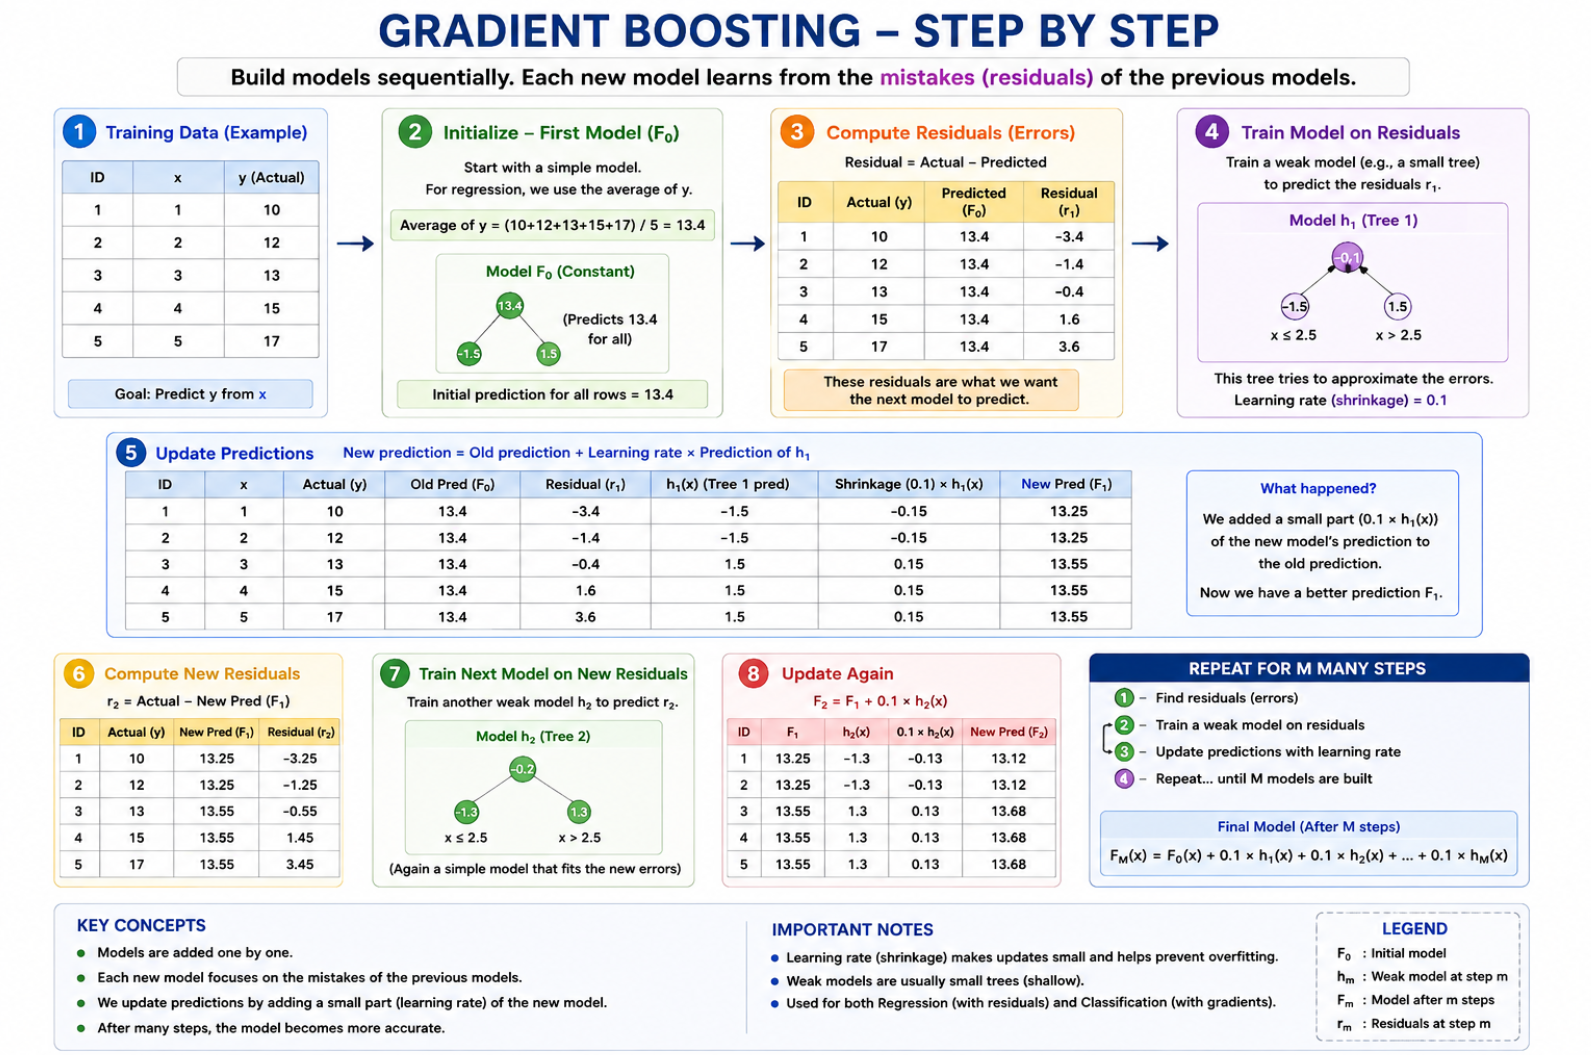

```text
Training Data (X, y)
        ↓
Create a simple initial model
        ↓
Make predictions
        ↓
Calculate residuals / errors
        ↓
Train a weak learner on the residuals
        ↓
Use its prediction as a small correction
        ↓
Update the overall predictions
        ↓
Calculate the remaining errors
        ↓
Train another weak learner
        ↓
Update predictions again
        ↓
Repeat for many boosting steps
        ↓
Final strong model
```

## Key Points to Remember

1. **Gradient Boosting trains models sequentially.**
2. Each new model tries to **correct the previous model's mistakes**.
3. The weak learners are commonly **small Decision Trees**.
4. The next learner is trained using the **residuals/errors**.
5. Each learner makes a **small correction** to the current predictions.
6. The **learning rate** controls the size of each correction.
7. Many weak learners are combined to create a **strong final model**.
8. The process continues for a chosen number of **boosting steps/trees**.
